In [1]:
%run 00_setup.ipynb

In [2]:
RUN_ID = REFERENCE_RUN   # = 2, a execucao de referencia (a adjudicada); mude para analisar outra
ann    = load("annotations.csv", run=RUN_ID)
gold   = load("gold.csv", run=RUN_ID)
status = load("status.csv", run=RUN_ID)
fail   = load("failures.csv", run=RUN_ID)
dist   = load("pattern_distribution.csv", run=RUN_ID)
sample = load("sample.csv", run=RUN_ID)
meta   = load("meta.csv", run=RUN_ID).iloc[0].to_dict()

print(f"run {RUN_ID}: {meta['label']}  |  painel: {meta['panel']}")
print(f"{len(ann)} linhas de anotacao, {len(gold)} linhas de gold, {len(status)} linhas de estado, {len(fail)} linhas de falha")

run 2: llm_panel #2  |  painel: deepseek/deepseek-v4-flash;meta-llama/llama-3.3-70b-instruct;openai/gpt-oss-120b;qwen/qwen3-next-80b-a3b-instruct
67317 linhas de anotacao, 5000 linhas de gold, 3600 linhas de estado, 57 linhas de falha


### Nota
A adjudicação incidiu sobre uma amostra estratificada do *corpus*: as revisões silenciosas (em que o painel não sinalizou qualquer padrão) são fortemente sub-amostradas, e as sinalizadas são conservadas. Assim, as métricas de calibração são **condicionais a esta amostra**, e não ao nível do *corpus*. Convém ler a revocação (*recall*) como uma estimativa optimista, e conduzir a leitura pela precisão e pelo suporte por padrão.

In [3]:
sample["reviews"] = 1
sample.groupby("stratum").agg(reviews=("individualId","nunique"),
                              avg_selection_prob=("selectionProb","mean")).round(3)

,reviews,avg_selection_prob
stratum,,
flagged_majority,106,0.633
flagged_split,133,0.662
silent,145,0.116


## Passagem de adjudicação (`PASS`)
A referência conserva **duas passagens**. `open` é o *consenso adjudicado* em que o autor adjudicou com a maioria do painel pré-preenchida no ecrã (eficiente e executável em escala, mas com o painel à vista). `blind` é o autor a adjudicar apenas a partir do texto da avaliação (independente do painel, mas de menor dimensão). A análise de validade B e a análise de direcção C, abaixo, respeitam ambas este selector, pelo que se pode re-executar o notebook inteiro contra qualquer das referências. 

In [4]:
PASS = "open"

### Média harmónica
O F1 é a média harmónica da precisão e da revocação. Quem faz uma viagem de ida a 60 km/h e regressa a 20 km/h não tem uma velocidade média de 40 km/h, mas de 30 km/h, porque passa três vezes mais tempo no troço lento. A média harmónica pesa cada valor pelo «tempo» que ele consome e é, por isso, puxada pelo pior valor. Para pontuar bem no F1, é preciso pontuar bem nas duas componentes ao mesmo tempo.

## Análise B: calibração contra a referência (validade)
Estará cada modelo *certo*, face ao `final_label` adjudicado pelo autor? Precisão / revocação / F1 por par (modelo, padrão). A `panel_majority` é pontuada como mais um «modelo». A `macro` faz a média sobre os padrões com igual peso, para que os padrões raros não fiquem abafados.

In [5]:
cell_df = cells(ann, gold, PASS)
macro(calibration(cell_df))

,precision,recall,f1
model,,,
deepseek/deepseek-v4-flash,0.518,0.139,0.204
meta-llama/llama-3.3-70b-instruct,0.512,0.197,0.272
openai/gpt-oss-120b,0.477,0.122,0.179
panel-majority,0.564,0.126,0.194
qwen/qwen3-next-80b-a3b-instruct,0.656,0.359,0.446


### *bootstrap*
Se o estudo fosse repetido com outras avaliações, o F1 macro seria, muito provavelmente, diferente — importa saber quanto poderia variar. 

A amostra de que dispomos é a melhor estimativa disponível da população, pelo que se simulam «novos estudos» reamostrando, com reposição, a própria amostra. Tal como nas sondagens não se realiza uma eleição nova para estimar a margem de erro, refazem-se 2 000 amostras sintéticas a partir da única que existe. Reamostram-se **avaliações** em vez de células, uma vez que as 19 células de uma avaliação partilham o mesmo texto e o mesmo adjudicador, pelo que não são independentes; reamostrar células produziria intervalos demasiado estreitos.

In [6]:
bootstrap_macro_f1(cell_df)

{'deepseek/deepseek-v4-flash': (np.float64(0.148), np.float64(0.245)),
 'meta-llama/llama-3.3-70b-instruct': (np.float64(0.204), np.float64(0.314)),
 'openai/gpt-oss-120b': (np.float64(0.12), np.float64(0.226)),
 'qwen/qwen3-next-80b-a3b-instruct': (np.float64(0.36), np.float64(0.488)),
 'panel-majority': (np.float64(0.132), np.float64(0.242))}

Em 95% dos estudos alternativos simulados, o F1 macro caiu dentro do intervalo respectivo. Um segundo modelo cujo intervalo se sobreponha não se distingue do primeiro com confiança. Dois pormenores do código: o `default_rng(0)` define a semente do gerador, pelo que o intervalo é reproduzível; e o `merge` com `how="left"` traz todas as células de cada avaliação escolhida, incluindo as repetidas, que é o que a reposição exige.

A revocação baixa, aqui, é esperada, uma vez que a amostra estratificada enriquece as revisões difíceis (*silent/split*), em que o painel é conservador e omite padrões que o autor acrescentou. Convém conduzir a leitura pela **precisão** e pela coluna de **suporte**; desaconselha-se ler como resultado uma métrica assente em 2 a 3 positivos.

### Posição face ao anotador humano: κ e concordância bruta
A calibração responde «acerta?»; esta leitura responde «concorda com o humano como um anotador?». Sobre todas as células (revisão × padrão), calcula-se por modelo a **concordância bruta** (fracção de células iguais) e o **κ de Cohen** (a mesma concordância, corrigida do acaso). A leitura conduz-se pelo κ, uma vez que, com classes desequilibradas, acertar «ausente» quase sempre garante uma bruta alta sem atestar capacidade de detecção. Nas bandas de Landis e Koch, 0,41–0,60 lê-se «moderado».

In [7]:
from sklearn.metrics import cohen_kappa_score
pos = []
for m, d in cell_df.groupby("model"):
    pos.append({"model": m, "bruta": round((d["y_true"] == d["y_pred"]).mean(), 3),
                "kappa": round(cohen_kappa_score(d["y_true"], d["y_pred"]), 3)})
pd.DataFrame(pos).set_index("model").sort_values("kappa", ascending=False)

,bruta,kappa
model,,
qwen/qwen3-next-80b-a3b-instruct,0.956,0.593
meta-llama/llama-3.3-70b-instruct,0.951,0.482
deepseek/deepseek-v4-flash,0.945,0.392
panel-majority,0.946,0.377
openai/gpt-oss-120b,0.944,0.365


### Granularidades: macro, micro e binária
O mesmo instrumento responde de forma muito distinta consoante a granularidade da pergunta. **Macro** = média por padrão com peso igual (a convenção mais exigente, adoptada por omissão nestes notebooks). **Micro** = todas as células agregadas. **Binária** = por revisão, «existe algum padrão nesta revisão?» (o máximo das 19 decisões). Compara-se o melhor membro nas três

In [9]:
from sklearn.metrics import f1_score
best_slug = macro(calibration(cell_df)).drop(index="panel-majority")["f1"].idxmax()
d = cell_df[cell_df["model"] == best_slug]
mac = macro(calibration(d)).loc[best_slug, "f1"]
_, _, mic, _ = precision_recall_fscore_support(d["y_true"], d["y_pred"], average="binary", pos_label=1, zero_division=0)
por_rev = d.groupby("individualId")[["y_true", "y_pred"]].max()
bina = f1_score(por_rev["y_true"], por_rev["y_pred"])
print(f"melhor membro: {best_slug}")
print(f"F1 macro:   {mac:.3f}")
print(f"F1 micro:   {mic:.3f}")
print(f"F1 binária: {bina:.3f}  (n={len(por_rev)} revisões)")

melhor membro: qwen/qwen3-next-80b-a3b-instruct
F1 macro:   0.446
F1 micro:   0.615
F1 binária: 0.743  (n=230 revisões)


gravado: figures/fig-calibracao-ic.png


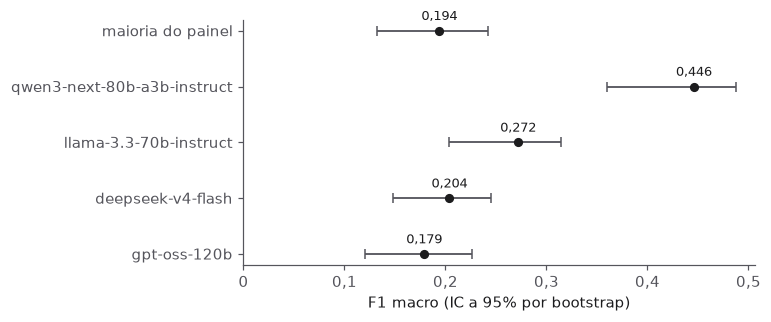

In [10]:
from matplotlib.ticker import FuncFormatter
plt = styled_plt()
cal = macro(calibration(cell_df))
ci  = bootstrap_macro_f1(cell_df)
nome = lambda m: "maioria do painel" if m == "panel-majority" else m.split("/")[-1]
membros = cal.drop(index="panel-majority").sort_values("f1")
ordem = list(membros.index) + ["panel-majority"]     # painel no topo do grafico
ys = range(len(ordem))
fig, ax = plt.subplots(figsize=(6.0, 2.9))
for y, m in zip(ys, ordem):
    f1 = cal.loc[m, "f1"]; lo, hi = ci[m]
    ax.errorbar(f1, y, xerr=[[f1 - lo], [hi - f1]], fmt="o", ms=5, color=INK, ecolor=MID, elinewidth=1.2, capsize=3)
    ax.annotate(virgula(f1), (f1, y), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8.5)
ax.set_yticks(list(ys)); ax.set_yticklabels([nome(m) for m in ordem])
ax.set_xlabel("F1 macro (IC a 95% por bootstrap)")
ax.xaxis.set_major_formatter(FuncFormatter(virgula))
ax.set_xlim(0, None)
save_fig(fig, "fig-calibracao-ic")

## A regra de agregação é uma *escolha*, não um facto
A `panel-majority` acima é uma **maioria estrita**: presente apenas quando ≥ 3 dos 4 modelos concordam (um empate de 2 contra 2 conta como ausente). Mas a regra vive neste notebook, e não nos dados: o `annotations.csv` conserva o voto bruto de cada modelo, pelo que se pode reagregar sob qualquer limiar com `panel_vote(ann, k, ...)`, sendo `k=1` a união («qualquer modelo sinaliza») e `k=4` a unanimidade. Como o painel *erra por omissão*, a regra estrita é a pior escolha possível para a revocação. Testem-se todos os valores de `k` e pontue-se cada regra contra a referência:

In [14]:
RULES = [(1, "panel-≥1 (union)"), (2, "panel-≥2"), (3, "panel-≥3 (strict maj)"), (4, "panel-≥4 (unanimous)")]
votes = pd.concat([panel_vote(ann, k, lab) for k, lab in RULES], ignore_index=True)
g = gold[gold["pass"] == PASS][["individualId", "code", "finalLabel"]]
sweep = votes.merge(g, on=["individualId", "code"], how="inner").rename(columns={"modelSlug": "model"})
sweep["y_true"] = sweep["finalLabel"].astype(int); sweep["y_pred"] = sweep["present"].astype(int)

def micro(cell_df):
    rows = []
    for model, d in cell_df.groupby("model"):
        p, r, f, _ = precision_recall_fscore_support(d["y_true"], d["y_pred"], average="binary", pos_label=1, zero_division=0)
        fires = d.loc[d["y_pred"] == 1, "code"].nunique()
        rows.append({"model": model, "precision": round(p,3), "recall": round(r,3), "f1": round(f,3), "patterns_fired": fires})
    return pd.DataFrame(rows).set_index("model").loc[[lab for _, lab in RULES]]

print("-- macro (por padrao, peso igual) --");  print(macro(calibration(sweep)).to_string())
print("\n-- micro (celulas agregadas) + em quantos dos 19 padroes cada regra chega a produzir positivos --"); print(micro(sweep).to_string())

-- macro (por padrao, peso igual) --
                       precision  recall     f1
model                                          
panel-≥1 (union)           0.616   0.405  0.467
panel-≥2                   0.559   0.216  0.296
panel-≥3 (strict maj)      0.507   0.112  0.175
panel-≥4 (unanimous)       0.421   0.062  0.103

-- micro (celulas agregadas) + em quantos dos 19 padroes cada regra chega a produzir positivos --
                       precision  recall     f1  patterns_fired
model                                                          
panel-≥1 (union)           0.764   0.595  0.669              18
panel-≥2                   0.898   0.370  0.524              14
panel-≥3 (strict maj)      0.972   0.222  0.361              10
panel-≥4 (unanimous)       1.000   0.138  0.243               8


### Quem sustenta a união?
A união parece render mais, mas importa decompor os seus verdadeiros positivos: que fracção já pertencia ao melhor membro isolado, e quantos é que os restantes três acrescentam? Este número impede a leitura «o conjunto supera o melhor membro».

In [12]:
uni = sweep[sweep["model"] == "panel-≥1 (union)"].set_index(["individualId", "code"])
tp_uni = uni[(uni["y_true"] == 1) & (uni["y_pred"] == 1)].index
melhor = cell_df[cell_df["model"] == best_slug].set_index(["individualId", "code"])
tp_melhor = set(melhor[(melhor["y_true"] == 1) & (melhor["y_pred"] == 1)].index)
ja = sum(1 for ix in tp_uni if ix in tp_melhor)
print(f"TP da união:                   {len(tp_uni)}")
print(f"já do melhor membro:           {ja} ({100*ja/len(tp_uni):.1f}%)")
print(f"acrescentados pelos restantes: {len(tp_uni) - ja}")

TP da união:                   185
já do melhor membro:           151 (81.6%)
acrescentados pelos restantes: 34


**Leia-se isto como uma análise de sensibilidade, e não como uma caça à «melhor» regra.** O limiar de agregação é uma escolha do investigador que move bastante os números, pelo que importa reportar todas as regras, em vez de eleger um valor. Duas leituras honestas. **(1) O limiar move bastante os resultados e a maioria estrita é conservadora por construção.** Ao baixá-lo, a revocação sobe e a precisão cai (micro ≥3 → ≥1: P 0,97 → 0,76, R 0,22 → 0,60), e a maioria estrita só produz positivos em cerca de 10 dos 19 padrões, por a concordância de três em quatro ser rara num painel que já falha por omissão. **(2) As regras permissivas não provam valor do conjunto (*ensemble*).** Como a célula acima mostra, 81,6% dos verdadeiros positivos da união já pertencem ao melhor membro isolado; os três modelos restantes acrescentam 34 ao preço de falsos positivos adicionais. A união superar o melhor membro é, por isso, uma leitura a evitar: o painel vale pela fiabilidade mensurável entre anotadores e pela robustez a falhas, e não por bater o seu melhor membro. A leitura operacional mantém-se na maioria estrita, a regra que o ecrã de adjudicação efectivamente mostrou; as restantes são «e se».

gravado: figures/fig-sensibilidade-agregacao.png


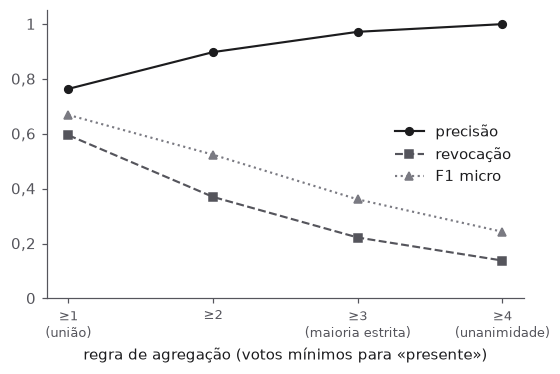

In [13]:
from matplotlib.ticker import FuncFormatter
plt = styled_plt()
mi = micro(sweep)
x = list(range(len(mi)))
rotulos = ["≥1\n(união)", "≥2", "≥3\n(maioria estrita)", "≥4\n(unanimidade)"]
fig, ax = plt.subplots(figsize=(5.6, 3.4))
series = [("precision", "precisão", "o", "-", INK), ("recall", "revocação", "s", "--", MID), ("f1", "F1 micro", "^", ":", "#7a7a82")]
for col, lab, mk, ls, cor in series:
    ax.plot(x, mi[col], marker=mk, ms=5, ls=ls, lw=1.4, color=cor, label=lab)
ax.set_xticks(x); ax.set_xticklabels(rotulos, fontsize=8.5)
ax.set_xlabel("regra de agregação (votos mínimos para «presente»)")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(FuncFormatter(virgula))
ax.legend(loc="center right")
save_fig(fig, "fig-sensibilidade-agregacao")